In [1]:
# Cell 1: Import libraries dan setup
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
data = pd.read_csv("./generated_data.csv")

df = pd.DataFrame(data)

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nStatistical summary:")
print(df.describe())

Dataset shape: (474, 7)

First 5 rows:
   tinggi_badan_cm  umur_tahun  batuk_lama  demam  keringat_malam  \
0              198           5       False  False           False   
1              156          26       False  False           False   
2              172          12       False  False           False   
3              180          39        True  False           False   
4              165          18       False  False           False   

   penurunan_berat_badan  skor_risiko_tb  
0                  False          0.0354  
1                  False          0.2457  
2                  False          0.1023  
3                  False          0.3829  
4                  False          0.1741  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474 entries, 0 to 473
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tinggi_badan_cm        474 non-null    int64  
 1   umur_tah

In [ ]:
# Cell 3: Preprocessing
# Convert boolean to numeric (0 and 1)
df['batuk_lama'] = df['batuk_lama'].astype(int)
df['demam'] = df['demam'].astype(int)
df['keringat_malam'] = df['keringat_malam'].astype(int)
df['penurunan_berat_badan'] = df['penurunan_berat_badan'].astype(int)

# Separate features (X) and target (y)
X = df.drop('skor_risiko_tb', axis=1)
y = df['skor_risiko_tb']

print("Features (X):")
print(X.head())
print(f"\nTarget (y) - skor_risiko_tb:")
print(y.head())
print(f"\nFeature columns: {list(X.columns)}")

Features (X):
   tinggi_badan_cm  umur_tahun  batuk_lama  demam  keringat_malam  \
0              198           5           0      0               0   
1              156          26           0      0               0   
2              172          12           0      0               0   
3              180          39           1      0               0   
4              165          18           0      0               0   

   penurunan_berat_badan  
0                      0  
1                      0  
2                      0  
3                      0  
4                      0  

Target (y) - skor_risiko_tb:
0    0.0354
1    0.2457
2    0.1023
3    0.3829
4    0.1741
Name: skor_risiko_tb, dtype: float64

Feature columns: ['tinggi_badan_cm', 'umur_tahun', 'batuk_lama', 'demam', 'keringat_malam', 'penurunan_berat_badan']


In [ ]:
# Cell 4: Split data dan normalisasi
# Split into train and test sets (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features (penting untuk model linear)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nFeature scaling completed!")

Training set size: 379 samples
Test set size: 95 samples

Feature scaling completed!


In [ ]:
# Cell 5: Train multiple models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=3)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print('='*50)
    
    # Train (Linear Regression perlu data scaled, tree-based tidak)
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'predictions': y_pred
    }
    
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")

# Find best model
best_model_name = min(results, key=lambda x: results[x]['rmse'])
print(f"\n{'='*50}")
print(f"BEST MODEL: {best_model_name}")
print(f"RMSE: {results[best_model_name]['rmse']:.4f}")
print(f"R² Score: {results[best_model_name]['r2']:.4f}")
print('='*50)


Training Linear Regression...
Mean Squared Error (MSE): 0.0002
Root Mean Squared Error (RMSE): 0.0136
Mean Absolute Error (MAE): 0.0109
R² Score: 0.9936

Training Random Forest...
Mean Squared Error (MSE): 0.0001
Root Mean Squared Error (RMSE): 0.0093
Mean Absolute Error (MAE): 0.0039
R² Score: 0.9970

Training Gradient Boosting...
Mean Squared Error (MSE): 0.0001
Root Mean Squared Error (RMSE): 0.0074
Mean Absolute Error (MAE): 0.0039
R² Score: 0.9981

BEST MODEL: Gradient Boosting
RMSE: 0.0074
R² Score: 0.9981



Random Forest - Feature Importance:
                 feature  importance
2             batuk_lama    0.807285
1             umur_tahun    0.159243
0        tinggi_badan_cm    0.030757
3                  demam    0.001245
4         keringat_malam    0.001031
5  penurunan_berat_badan    0.000438


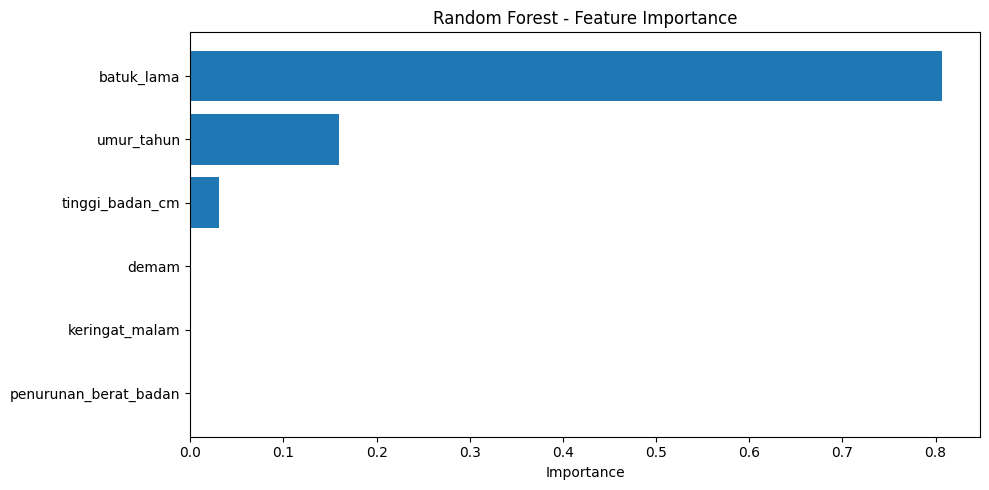


Gradient Boosting - Feature Importance:
                 feature  importance
2             batuk_lama    0.741017
1             umur_tahun    0.251435
0        tinggi_badan_cm    0.003854
4         keringat_malam    0.001911
3                  demam    0.001299
5  penurunan_berat_badan    0.000484


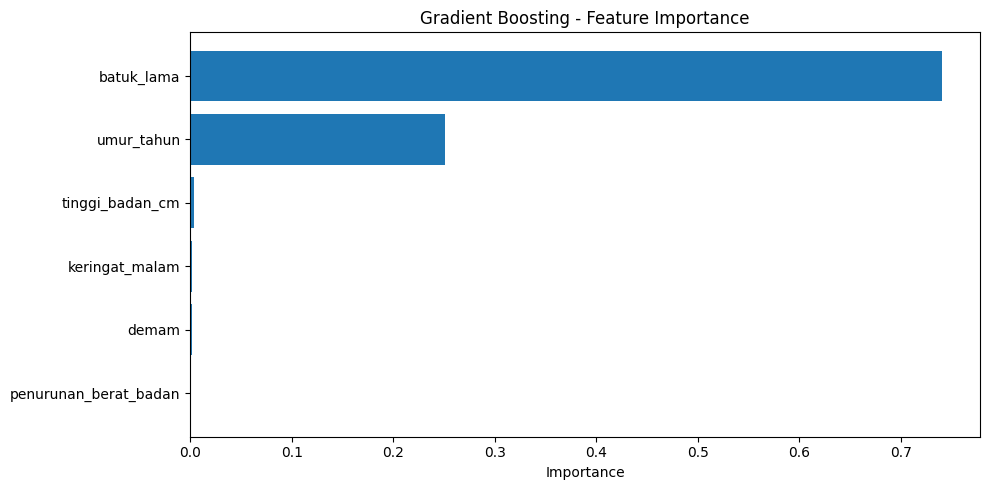

In [ ]:
# Cell 6: Feature importance (untuk Random Forest dan Gradient Boosting)
import matplotlib.pyplot as plt

for name in ['Random Forest', 'Gradient Boosting']:
    model = results[name]['model']
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n{name} - Feature Importance:")
    print(feature_importance)
    
    plt.figure(figsize=(10, 5))
    plt.barh(feature_importance['feature'], feature_importance['importance'])
    plt.xlabel('Importance')
    plt.title(f'{name} - Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [ ]:
# Cell 7: Save best model
best_model = results[best_model_name]['model']

# Save model dan scaler
joblib.dump(best_model, 'tb_risk_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"✓ Model saved: tb_risk_model.pkl")
print(f"✓ Scaler saved: scaler.pkl")
print(f"\nBest model: {best_model_name}")

✓ Model saved: tb_risk_model.pkl
✓ Scaler saved: scaler.pkl

Best model: Gradient Boosting


In [ ]:
# Cell 8: Fungsi prediksi untuk deployment
def predict_tb_risk(tinggi_badan_cm, umur_tahun, batuk_lama, demam, 
                    keringat_malam, penurunan_berat_badan):
    """
    Prediksi skor risiko TB berdasarkan gejala pasien
    
    Parameters:
    - tinggi_badan_cm: int (cm)
    - umur_tahun: int (tahun)
    - batuk_lama: bool (True/False)
    - demam: bool (True/False)
    - keringat_malam: bool (True/False)
    - penurunan_berat_badan: bool (True/False)
    
    Returns:
    - skor_risiko: float (0-1)
    - kategori: str ('Low Risk', 'Medium Risk', 'High Risk')
    - rekomendasi: bool (perlu pemeriksaan dokter)
    """
    # Load model
    model = joblib.load('tb_risk_model.pkl')
    scaler = joblib.load('scaler.pkl')
    loaded_model = joblib.load('tb_risk_model.pkl')
    print(f"Loaded model type: {type(loaded_model)}")
    print(f"Model: {loaded_model}")
    # Prepare input
    input_data = pd.DataFrame({
        'tinggi_badan_cm': [tinggi_badan_cm],
        'umur_tahun': [umur_tahun],
        'batuk_lama': [int(batuk_lama)],
        'demam': [int(demam)],
        'keringat_malam': [int(keringat_malam)],
        'penurunan_berat_badan': [int(penurunan_berat_badan)],
    })
    
    # Predict
    if best_model_name == 'Linear Regression':
        input_scaled = scaler.transform(input_data)
        skor_risiko = model.predict(input_scaled)[0]
    else:
        skor_risiko = model.predict(input_data)[0]
    
    # Clip to [0, 1] range
    skor_risiko = np.clip(skor_risiko, 0, 1)
    
    # Kategorisasi
    if skor_risiko < 0.4:
        kategori = 'Low Risk'
        rekomendasi = False
    elif skor_risiko < 0.7:
        kategori = 'Medium Risk'
        rekomendasi = True
    else:
        kategori = 'High Risk'
        rekomendasi = True
    
    return {
        'skor_risiko_tb': round(skor_risiko, 4),
        'kategori': kategori,
        'rekomendasi_pemeriksaan_dokter': rekomendasi
    }

print("✓ Fungsi prediksi siap digunakan!")

✓ Fungsi prediksi siap digunakan!


In [ ]:
# Cell 9: Test prediksi dengan data contoh Anda
print("Testing dengan data sample Anda:")
print("="*60)

test_case = {
    'tinggi_badan_cm': 200,
    'umur_tahun': 44,
    'batuk_lama': False,
    'demam': True,
    'keringat_malam': False,
    'penurunan_berat_badan': True
}

result = predict_tb_risk(**test_case)

print(f"Input:")
for key, value in test_case.items():
    print(f"  {key}: {value}")

print(f"\nHasil Prediksi:")
print(f"  Skor Risiko TB: {result['skor_risiko_tb']:.4f}")
print(f"  Kategori: {result['kategori']}")
print(f"  Rekomendasi Pemeriksaan Dokter: {result['rekomendasi_pemeriksaan_dokter']}")

print("\n" + "="*60)
print("Testing dengan beberapa kasus lain:")
print("="*60)

# Test case 2: Low risk
print("\nCase 2 - Low Risk (tidak ada gejala berat):")
result2 = predict_tb_risk(130, 12, False, False, False, False)
print(f"  Skor: {result2['skor_risiko_tb']:.4f} | Kategori: {result2['kategori']}")

# Test case 3: High risk
print("\nCase 3 - High Risk (semua gejala):")
result3 = predict_tb_risk(165, 55, True, True, True, True)
print(f"  Skor: {result3['skor_risiko_tb']:.4f} | Kategori: {result3['kategori']}")

# Test case 4: Medium risk
print("\nCase 4 - Medium Risk (beberapa gejala):")
result4 = predict_tb_risk(175, 40, True, False, True, False)
print(f"  Skor: {result4['skor_risiko_tb']:.4f} | Kategori: {result4['kategori']}")

Testing dengan data sample Anda:
Loaded model type: <class 'sklearn.ensemble._gb.GradientBoostingRegressor'>
Model: GradientBoostingRegressor(random_state=42)
Input:
  tinggi_badan_cm: 200
  umur_tahun: 44
  batuk_lama: False
  demam: True
  keringat_malam: False
  penurunan_berat_badan: True

Hasil Prediksi:
  Skor Risiko TB: 0.3694
  Kategori: Low Risk
  Rekomendasi Pemeriksaan Dokter: False

Testing dengan beberapa kasus lain:

Case 2 - Low Risk (tidak ada gejala berat):
Loaded model type: <class 'sklearn.ensemble._gb.GradientBoostingRegressor'>
Model: GradientBoostingRegressor(random_state=42)
  Skor: 0.1082 | Kategori: Low Risk

Case 3 - High Risk (semua gejala):
Loaded model type: <class 'sklearn.ensemble._gb.GradientBoostingRegressor'>
Model: GradientBoostingRegressor(random_state=42)
  Skor: 0.5318 | Kategori: Medium Risk

Case 4 - Medium Risk (beberapa gejala):
Loaded model type: <class 'sklearn.ensemble._gb.GradientBoostingRegressor'>
Model: GradientBoostingRegressor(random_s

In [ ]:
# Cell 10: Summary dan next steps
print("""
═══════════════════════════════════════════════════════════════
                    MODEL SUMMARY
═══════════════════════════════════════════════════════════════

✓ Model Type: Regression (Classical ML - NOT Deep Learning)
✓ Algorithms Tested: Linear Regression, Random Forest, Gradient Boosting
✓ Best Model Saved: tb_risk_model.pkl
✓ Scaler Saved: scaler.pkl

INPUT FEATURES:
  1. tinggi_badan_cm (numeric)
  2. umur_tahun (numeric)
  3. batuk_lama (boolean → 0/1)
  4. demam (boolean → 0/1)
  5. keringat_malam (boolean → 0/1)
  6. penurunan_berat_badan (boolean → 0/1)

OUTPUT:
  - skor_risiko_tb: float (0-1)
  - kategori: Low Risk (<0.4) | Medium Risk (0.4-0.7) | High Risk (>0.7)
  - rekomendasi_pemeriksaan_dokter: boolean

NEXT STEPS:
  1. Ganti dataset sample dengan data REAL dari klinik/RS Anda
     (minimal 100-1000 data untuk akurasi baik)
  2. Re-train model dengan data real
  3. Integrate fungsi predict_tb_risk() ke backend NestJS Anda
  4. Deploy model menggunakan Flask/FastAPI atau langsung di backend

UNTUK INTEGRASI KE BACKEND:
  - Install di backend: pip install pandas scikit-learn joblib
  - Copy file: tb_risk_model.pkl dan scaler.pkl
  - Import fungsi predict_tb_risk atau buat API endpoint

═══════════════════════════════════════════════════════════════
""")


═══════════════════════════════════════════════════════════════
                    MODEL SUMMARY
═══════════════════════════════════════════════════════════════

✓ Model Type: Regression (Classical ML - NOT Deep Learning)
✓ Algorithms Tested: Linear Regression, Random Forest, Gradient Boosting
✓ Best Model Saved: tb_risk_model.pkl
✓ Scaler Saved: scaler.pkl

INPUT FEATURES:
  1. tinggi_badan_cm (numeric)
  2. umur_tahun (numeric)
  3. batuk_lama (boolean → 0/1)
  4. demam (boolean → 0/1)
  5. keringat_malam (boolean → 0/1)
  6. penurunan_berat_badan (boolean → 0/1)

OUTPUT:
  - skor_risiko_tb: float (0-1)
  - kategori: Low Risk (<0.4) | Medium Risk (0.4-0.7) | High Risk (>0.7)
  - rekomendasi_pemeriksaan_dokter: boolean

NEXT STEPS:
  1. Ganti dataset sample dengan data REAL dari klinik/RS Anda
     (minimal 100-1000 data untuk akurasi baik)
  2. Re-train model dengan data real
  3. Integrate fungsi predict_tb_risk() ke backend NestJS Anda
  4. Deploy model menggunakan Flask/FastAPI 

In [ ]:
from tensorflow.keras.models import load_model

# Load the .h5 model
model = load_model('chest_xray_classification_model.h5')

# Save it in .keras format
model.save('chest_xray_classification_model.keras')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\annab\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\annab\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\annab\Documents\ASLAB_STUFF\Qualif_DeepLearning\environments\deep_learning\lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\annab\Documents\ASLAB_STUFF\Qualif_DeepL

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\annab\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\annab\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\annab\Documents\ASLAB_STUFF\Qualif_DeepLearning\environments\deep_learning\lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\annab\Documents\ASLAB_STUFF\Qualif_DeepL

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\annab\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\annab\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\annab\Documents\ASLAB_STUFF\Qualif_DeepLearning\environments\deep_learning\lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\annab\Documents\ASLAB_STUFF\Qualif_DeepL

AttributeError: _UFUNC_API not found

ImportError: numpy.core.umath failed to import

TypeError: Unable to convert function return value to a Python type! The signature was
	() -> handle